In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# 1) Write the code for Logistic regression with 2 features, 100 samples and 2 classes 
# (by scratch and visualize the result.) 

In [3]:
np.random.seed(42)

c1 = np.random.rand(50, 2) + np.array([2, 2])
c2 = np.random.rand(50, 2) + np.array([6, 6])

In [7]:
X = np.vstack([c1, c2])

In [8]:
y = np.hstack((np.zeros(50), np.ones(50)))

In [9]:
# normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [10]:
m, n = X.shape
weights = np.zeros(n)
bias = 0

In [11]:
m, n

(100, 2)

In [12]:

learning_rate = 0.1
epochs = 1000

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [14]:
for i in range(epochs):
    
    # Linear equation
    z = np.dot(X, weights) + bias
    
    # Prediction
    y_pred = sigmoid(z)
    
    # Gradients
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    
    # Update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

In [15]:
z = np.dot(X, weights) + bias
y_pred = sigmoid(z)
predictions = (y_pred >= 0.5).astype(int)

In [17]:
# Accuracy
accuracy = np.mean(predictions == y)
print("Accuracy:", accuracy)

Accuracy: 1.0


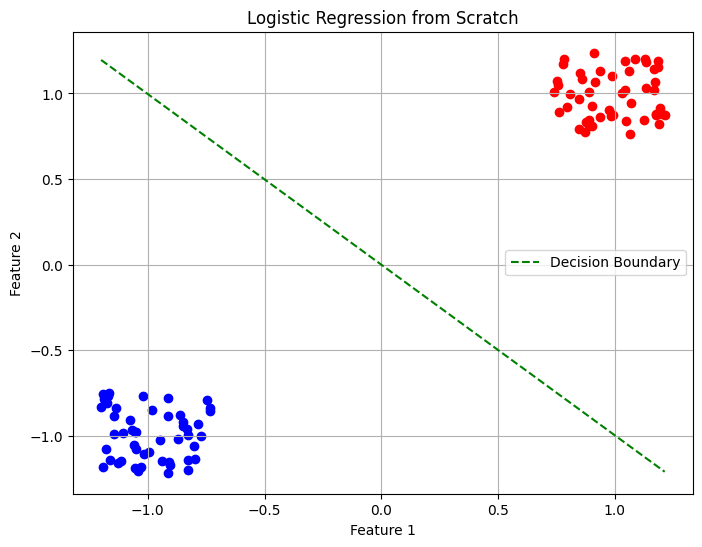

In [23]:
plt.figure(figsize=(8,6))

# Plot points
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='blue')
    else:
        plt.scatter(X[i,0], X[i,1], color='red')

# Decision Boundary
x_values = np.array([X[:,0].min(), X[:,0].max()])
y_values = -(weights[0]*x_values + bias) / weights[1]
plt.plot(x_values, y_values, color='green', linestyle="--", label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression from Scratch")
plt.legend()
plt.grid(True)
plt.show()